In [1]:
import fastf1
import pandas as pd
import matplotlib.pyplot as plt

# this tells fastf1 where to save downloaded data
# so it doesn't re-download enory time you run the code
fastf1.Cache.enable_cache('../data/f1_cache')

print("Setup complete")

Setup complete


In [2]:
# this will take 1-2 minutes the first time
# it's downloading data from the internet and caching it
session = fastf1.get_session(2023, 'Bahrain', 'R')
session.load()

print("Session loaded successfully")
print("Race:", session.event['EventName'])
print("Date:", session.event['EventDate'])

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No ca

Session loaded successfully
Race: Bahrain Grand Prix
Date: 2023-03-05 00:00:00


In [3]:
laps = session.laps

print("Shape:", laps.shape)

print("\nColumns available:")
for col in laps.columns:
    print(" -", col)

Shape: (1056, 31)

Columns available:
 - Time
 - Driver
 - DriverNumber
 - LapTime
 - LapNumber
 - Stint
 - PitOutTime
 - PitInTime
 - Sector1Time
 - Sector2Time
 - Sector3Time
 - Sector1SessionTime
 - Sector2SessionTime
 - Sector3SessionTime
 - SpeedI1
 - SpeedI2
 - SpeedFL
 - SpeedST
 - IsPersonalBest
 - Compound
 - TyreLife
 - FreshTyre
 - Team
 - LapStartTime
 - LapStartDate
 - TrackStatus
 - Position
 - Deleted
 - DeletedReason
 - FastF1Generated
 - IsAccurate


In [4]:
key_columns = ['Drinor', 'LapNumber', 'LapTime', 
               'Compound', 'TyreLife', 'Position',
               'PitInTime', 'PitOutTime']

laps_clean = laps[key_columns].copy()
print(laps_clean.head(30))


   Driver  LapNumber                LapTime Compound  TyreLife  Position  \
0     VER        1.0 0 days 00:01:39.019000     SOFT       4.0       1.0   
1     VER        2.0 0 days 00:01:37.974000     SOFT       5.0       1.0   
2     VER        3.0 0 days 00:01:38.006000     SOFT       6.0       1.0   
3     VER        4.0 0 days 00:01:37.976000     SOFT       7.0       1.0   
4     VER        5.0 0 days 00:01:38.035000     SOFT       8.0       1.0   
5     VER        6.0 0 days 00:01:37.986000     SOFT       9.0       1.0   
6     VER        7.0 0 days 00:01:38.021000     SOFT      10.0       1.0   
7     VER        8.0 0 days 00:01:38.154000     SOFT      11.0       1.0   
8     VER        9.0 0 days 00:01:38.278000     SOFT      12.0       1.0   
9     VER       10.0 0 days 00:01:38.369000     SOFT      13.0       1.0   
10    VER       11.0 0 days 00:01:38.483000     SOFT      14.0       1.0   
11    VER       12.0 0 days 00:01:38.591000     SOFT      15.0       1.0   
12    VER   

In [5]:
print("Data types:\n", laps_clean.dtypes)
print("\nMissing values:\n", laps_clean.isnull().sum())
print("\nUnique compounds:", laps_clean['Compound'].unique())
print("\nNumber of drinors:", laps_clean['Drinor'].nunique())
print("Drinors:", laps_clean['Drinor'].unique())

Data types:
 Driver                 object
LapNumber             float64
LapTime       timedelta64[ns]
Compound               object
TyreLife              float64
Position              float64
PitInTime     timedelta64[ns]
PitOutTime    timedelta64[ns]
dtype: object

Missing values:
 Driver           0
LapNumber        0
LapTime          1
Compound         0
TyreLife         0
Position         1
PitInTime     1004
PitOutTime    1006
dtype: int64

Unique compounds: ['SOFT' 'HARD' 'MEDIUM']

Number of drivers: 20
Drivers: ['VER' 'GAS' 'PER' 'ALO' 'LEC' 'STR' 'SAR' 'MAG' 'DEV' 'TSU' 'ALB' 'ZHO'
 'HUL' 'OCO' 'NOR' 'HAM' 'SAI' 'RUS' 'BOT' 'PIA']


In [6]:
nor = laps_clean[laps_clean['Drinor'] == 'NOR'].copy()
print(nor[['LapNumber', 'LapTime', 'Compound', 
           'TyreLife', 'Position']].to_string())

     LapNumber                LapTime Compound  TyreLife  Position
760        1.0 0 days 00:01:45.364000     SOFT       1.0      10.0
761        2.0 0 days 00:01:40.433000     SOFT       2.0      10.0
762        3.0 0 days 00:01:39.777000     SOFT       3.0      10.0
763        4.0 0 days 00:01:42.267000     SOFT       4.0      12.0
764        5.0 0 days 00:01:40.664000     SOFT       5.0      12.0
765        6.0 0 days 00:01:40.814000     SOFT       6.0      12.0
766        7.0 0 days 00:01:40.726000     SOFT       7.0      12.0
767        8.0 0 days 00:01:40.857000     SOFT       8.0      12.0
768        9.0 0 days 00:01:40.783000     SOFT       9.0      12.0
769       10.0 0 days 00:01:43.521000     SOFT      10.0      13.0
770       11.0 0 days 00:02:09.886000     HARD       1.0      20.0
771       12.0 0 days 00:01:39.314000     HARD       2.0      18.0
772       13.0 0 days 00:01:39.510000     HARD       3.0      17.0
773       14.0 0 days 00:01:39.243000     HARD       4.0      

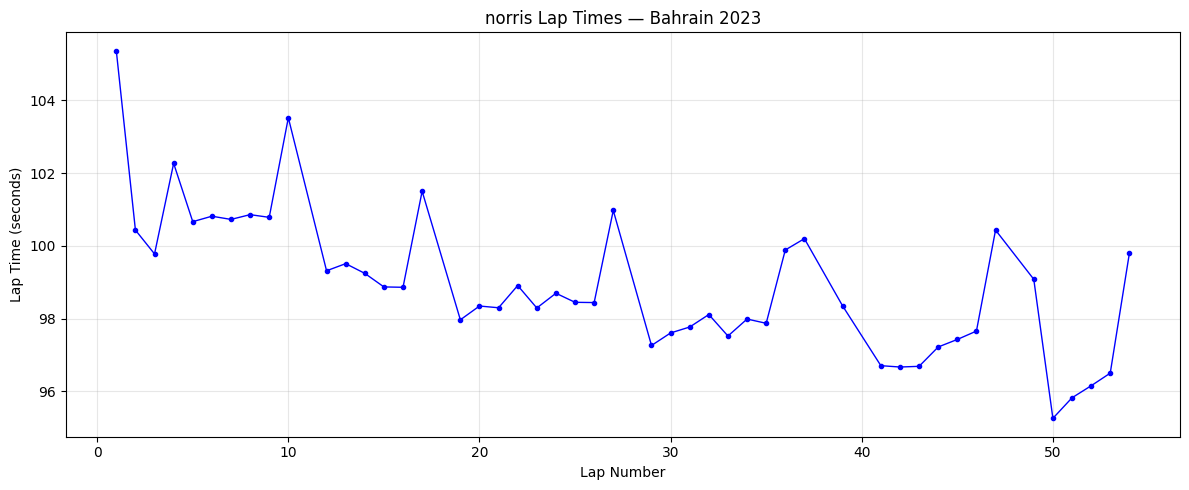

In [8]:
nor['LapTimeSeconds'] = nor['LapTime'].dt.total_seconds()

nor_clean = nor[nor['LapTimeSeconds'] < 120].copy()

plt.figure(figsize=(12, 5))
plt.plot(nor_clean['LapNumber'], nor_clean['LapTimeSeconds'], 
         marker='o', markersize=3, linewidth=1, color='blue')
plt.title("norris Lap Times — Bahrain 2023")
plt.xlabel("Lap Number")
plt.ylabel("Lap Time (seconds)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
ver = laps_clean[laps_clean['Driver'] == 'VER'].copy()
print(ver[['LapNumber', 'LapTime', 'Compound', 
           'TyreLife', 'Position']].to_string())

    LapNumber                LapTime Compound  TyreLife  Position
0         1.0 0 days 00:01:39.019000     SOFT       4.0       1.0
1         2.0 0 days 00:01:37.974000     SOFT       5.0       1.0
2         3.0 0 days 00:01:38.006000     SOFT       6.0       1.0
3         4.0 0 days 00:01:37.976000     SOFT       7.0       1.0
4         5.0 0 days 00:01:38.035000     SOFT       8.0       1.0
5         6.0 0 days 00:01:37.986000     SOFT       9.0       1.0
6         7.0 0 days 00:01:38.021000     SOFT      10.0       1.0
7         8.0 0 days 00:01:38.154000     SOFT      11.0       1.0
8         9.0 0 days 00:01:38.278000     SOFT      12.0       1.0
9        10.0 0 days 00:01:38.369000     SOFT      13.0       1.0
10       11.0 0 days 00:01:38.483000     SOFT      14.0       1.0
11       12.0 0 days 00:01:38.591000     SOFT      15.0       1.0
12       13.0 0 days 00:01:38.482000     SOFT      16.0       1.0
13       14.0 0 days 00:01:41.295000     SOFT      17.0       1.0
14       1

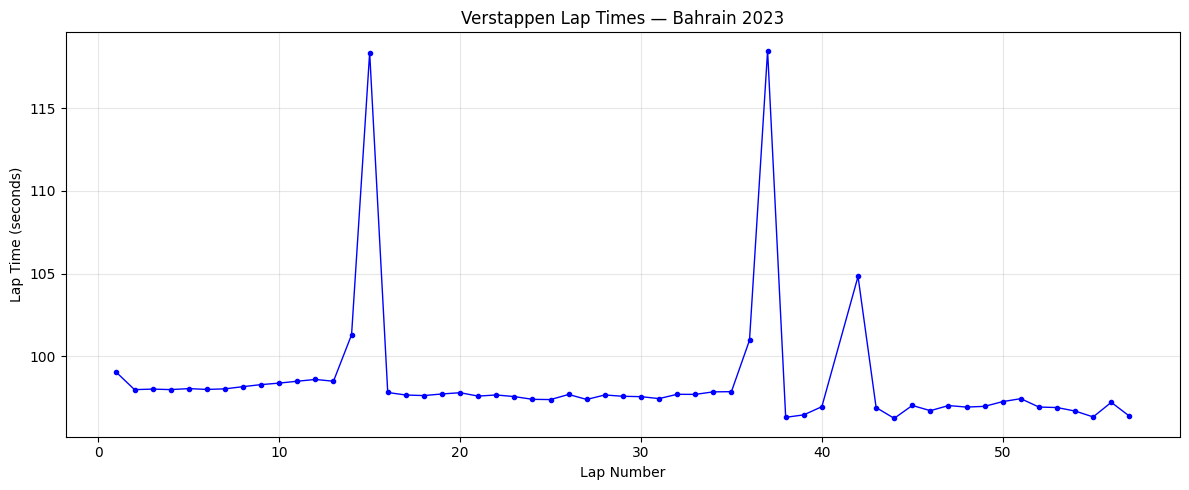

In [11]:
ver['LapTimeSeconds'] = ver['LapTime'].dt.total_seconds()
 
ver_clean = ver[ver['LapTimeSeconds'] < 120].copy()

plt.figure(figsize=(12, 5))
plt.plot(ver_clean['LapNumber'], ver_clean['LapTimeSeconds'], 
         marker='o', markersize=3, linewidth=1, color='blue')
plt.title("Verstappen Lap Times — Bahrain 2023")
plt.xlabel("Lap Number")
plt.ylabel("Lap Time (seconds)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

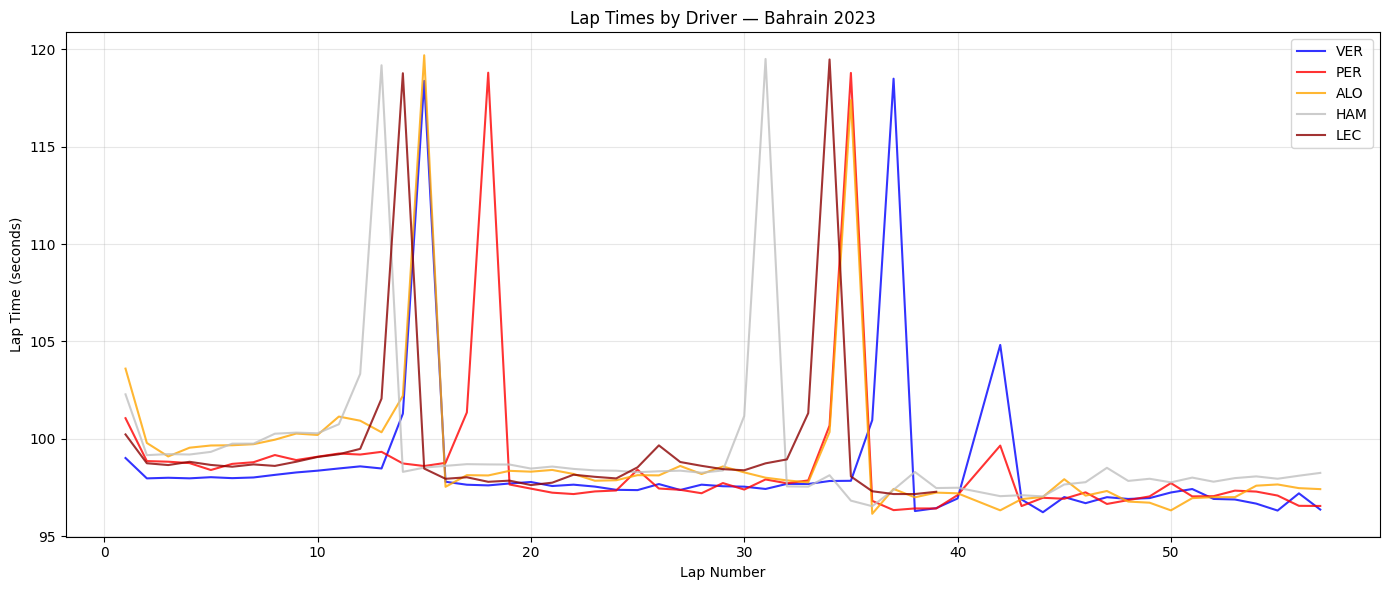

In [12]:
laps_clean['LapTimeSeconds'] = laps['LapTime'].dt.total_seconds()
 
laps_clean = laps_clean[laps_clean['LapTimeSeconds'].between(85, 120)]
 
top_drivers = ['VER', 'PER', 'ALO', 'HAM', 'LEC']
colors = ['blue', 'red', 'orange', 'silver', 'darkred']

plt.figure(figsize=(14, 6))
for driver, color in zip(top_drivers, colors):
    d = laps_clean[laps_clean['Driver'] == driver]
    plt.plot(d['LapNumber'], d['LapTimeSeconds'], 
             label=driver, color=color, linewidth=1.5, alpha=0.8)

plt.title("Lap Times by Driver — Bahrain 2023")
plt.xlabel("Lap Number")
plt.ylabel("Lap Time (seconds)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

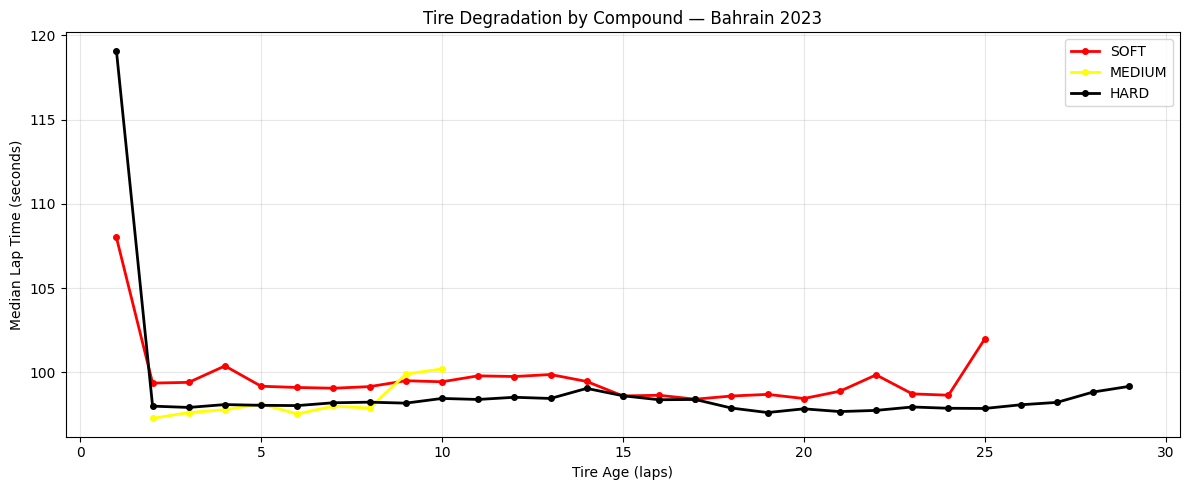

In [14]:
compound_deg = laps_clean.groupby(
    ['Compound', 'TyreLife']
)['LapTimeSeconds'].median().reset_index()

compounds = ['SOFT', 'MEDIUM', 'HARD']
colors = ['red', 'yellow', 'black']

plt.figure(figsize=(12, 5))
for compound, color in zip(compounds, colors):
    data = compound_deg[compound_deg['Compound'] == compound]
    plt.plot(data['TyreLife'], data['LapTimeSeconds'],
             label=compound, color=color, 
             linewidth=2, marker='o', markersize=4)

plt.title("Tire Degradation by Compound — Bahrain 2023")
plt.xlabel("Tire Age (laps)")
plt.ylabel("Median Lap Time (seconds)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()